In [ ]:
# Run this first!
import os, sys
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# fix google colab paths
os.chdir('/content/drive/MyDrive/AIinRT_block2_tutorials')  # adjust path if needed
sys.path.insert(0, '/content/drive/MyDrive/AIinRT_block2_tutorials/src')
sys.path.insert(0, '/content/drive/MyDrive/AIinRT_block2_tutorials/data')


import numpy as np
import matplotlib.pyplot as plt

from sklearn import svm

from src.plot_examples import plot_example_data
from src.digits_data import get_digits_data
from src.plot_confusion_matrices import plot_two_confusion_matrices

In [4]:
SEED = 42

X_train, X_test, y_train, y_test = get_digits_data(SEED, max_samples=None)

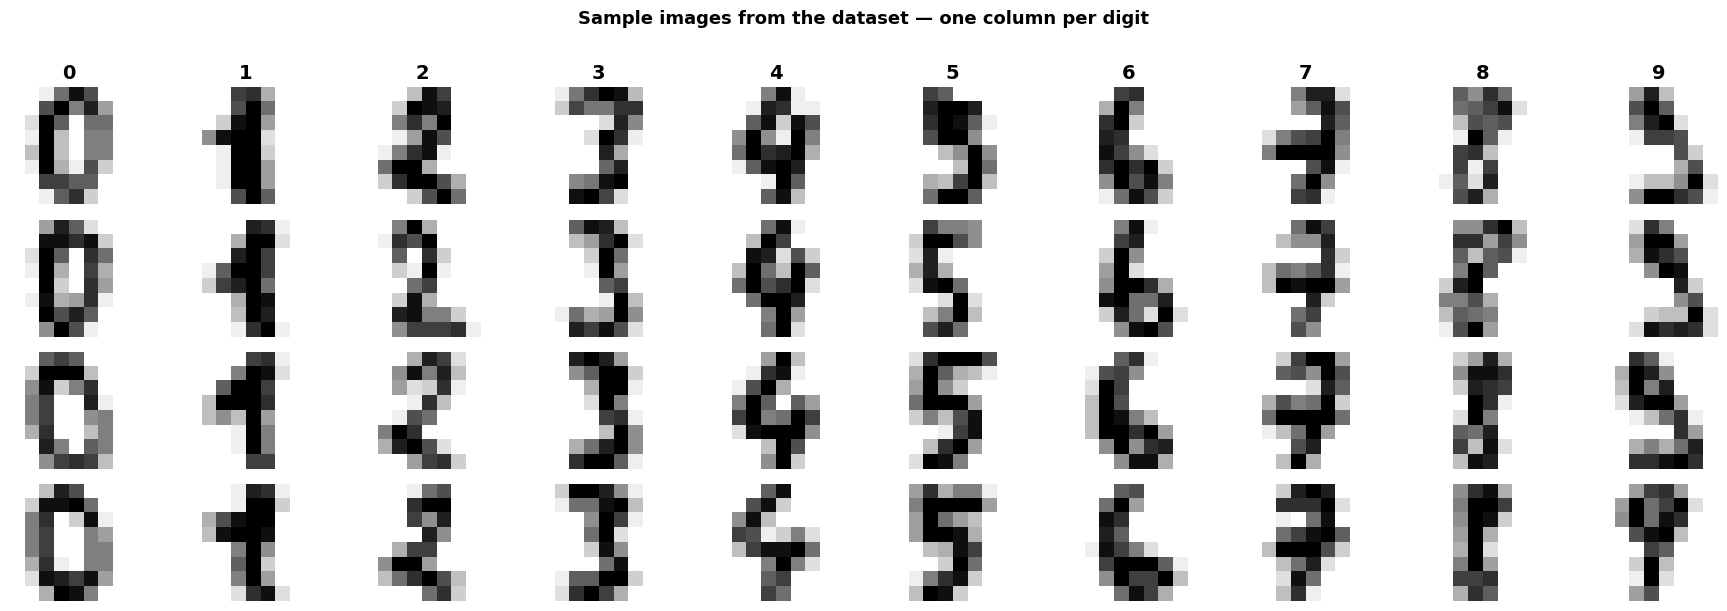

In [5]:
# view the data
from src.plot_examples import plot_example_data


plot_example_data(X_train, y_train, title="Sample images from the dataset — one column per digit")

# print("Each column shows 4 different handwritten versions of the same digit.")
# print("The AI must learn to recognise all of these as the same number.")

## 📦 Scenario 1: Data Completeness
### *Was the full range of information included in the training data?*

Imagine a hospital trained an auto-segmentation AI **only on adult patients**, but then started using it for **pediatric patients** too. 
The model has never seen that type of patient before!

In this demo: we train a model **all digits except for 8**, then ask it to also classify digit **8**.

In [6]:
# Model training

mask = y_train != 8
X_train_partial = X_train[mask]
y_train_partial = y_train[mask]

# Create a classifier: a support vector classifier
complete_model = svm.SVC(gamma=0.001)
partial_model = svm.SVC(gamma=0.001)

complete_model.fit(X_train, y_train)
partial_model.fit(X_train_partial, y_train_partial)


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",0.001
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


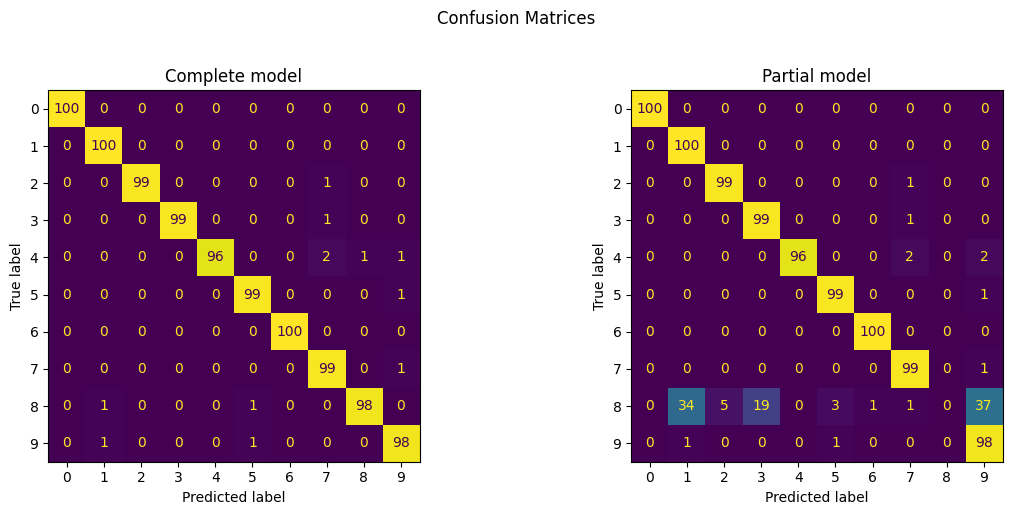

In [7]:
# Model evaluation 

# Predict the value of the digit on the test subset
complete_model_predicted = complete_model.predict(X_test)
partial_model_predicted = partial_model.predict(X_test)

# plot the results
plot_two_confusion_matrices(
    y_test,
    complete_model_predicted, "Complete model",
    partial_model_predicted, "Partial model",
)


## ✏️ Scenario 2: Data Correctness
### *Were the training labels accurate?*

AI models learn *from the labels given to training data*. If those labels are wrong, the model learns the wrong thing.

In radiotherapy: if an AI was trained on contours that were drawn inconsistently — perhaps one institution draws the parotid gland differently from another — the model absorbs that inconsistency.

In this demo: we **randomly flip some of the training labels** (tell the model that some "3"s are actually "7"s, etc.) and see how performance suffers.

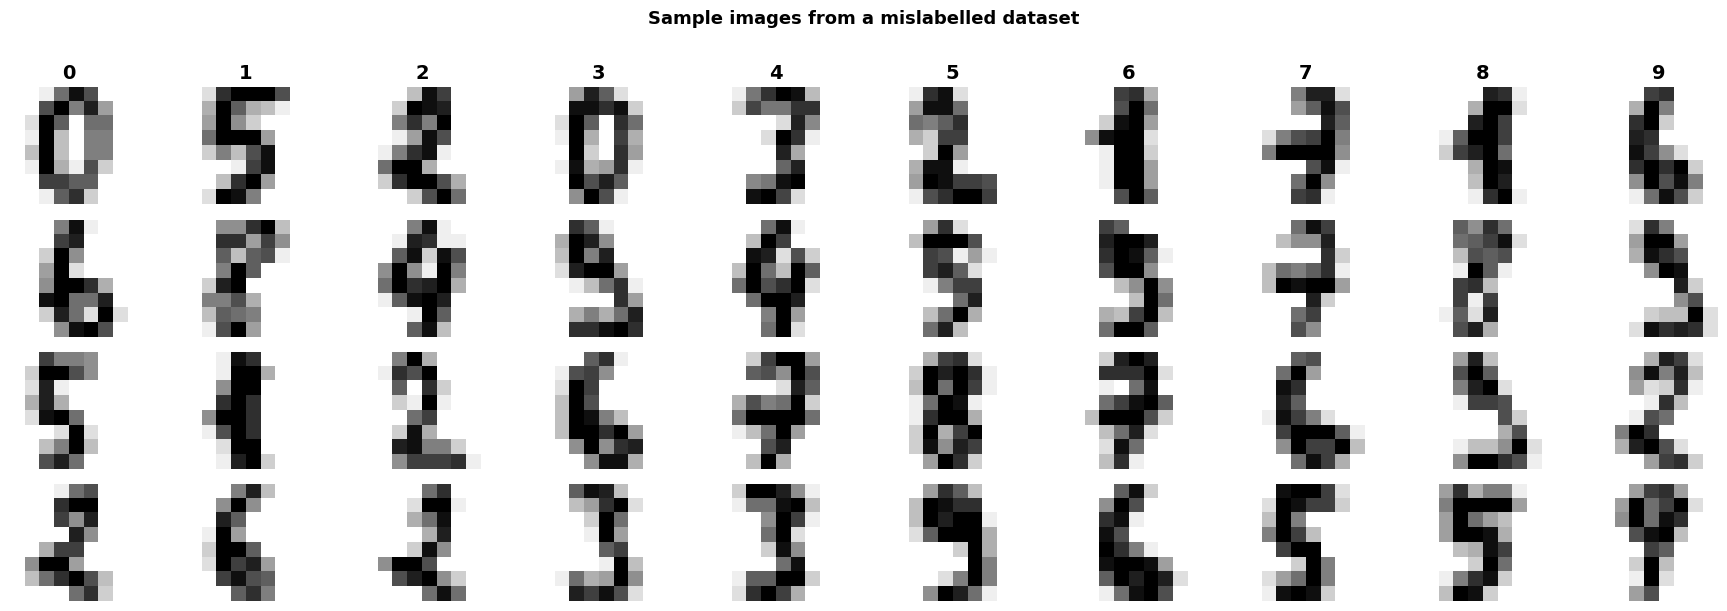

In [8]:
y_train_mislabelled = y_train.copy()
mislabelled_indices = np.random.RandomState(SEED).choice(len(y_train_mislabelled), size=int(0.7 * len(y_train_mislabelled)), replace=False)
y_train_mislabelled[mislabelled_indices] = np.random.RandomState(SEED).randint(0, 10, size=len(mislabelled_indices))

plot_example_data(X_train, y_train_mislabelled, title="Sample images from a mislabelled dataset")



In [9]:
# Model training

# Create a classifier: a support vector classifier
correct_model = svm.SVC(gamma=0.001)
mislabelled_model = svm.SVC(gamma=0.001)

correct_model.fit(X_train, y_train)
mislabelled_model.fit(X_train, y_train_mislabelled)


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",0.001
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


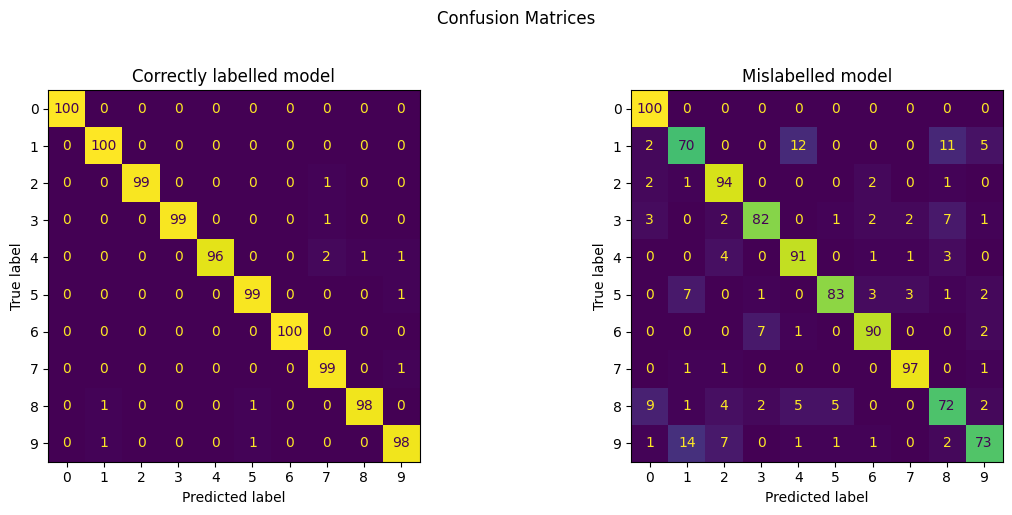

In [10]:
# Model evaluation

# Predict the value of the digit on the test subset
correct_model_predicted = correct_model.predict(X_test)
mislabelled_model_predicted = mislabelled_model.predict(X_test)

# plot the results
plot_two_confusion_matrices(
    y_test,
    correct_model_predicted, "Correctly labelled model",
    mislabelled_model_predicted, "Mislabelled model",
)


## 📡 Scenario 3: Data Quality
### *Were the training images clean and clear?*

Not all medical images are of equal quality. A CT scan taken on an old scanner with a non-standard protocol may look quite different from one taken on a modern machine. If the AI was trained only on high-quality images (e.g. planning CTs), it may fail on lower-quality inputs (e.g. cone beam CT) — and vice versa.

In this demo: we **add random noise** to the training images (like static on a TV) and observe the effect on performance.

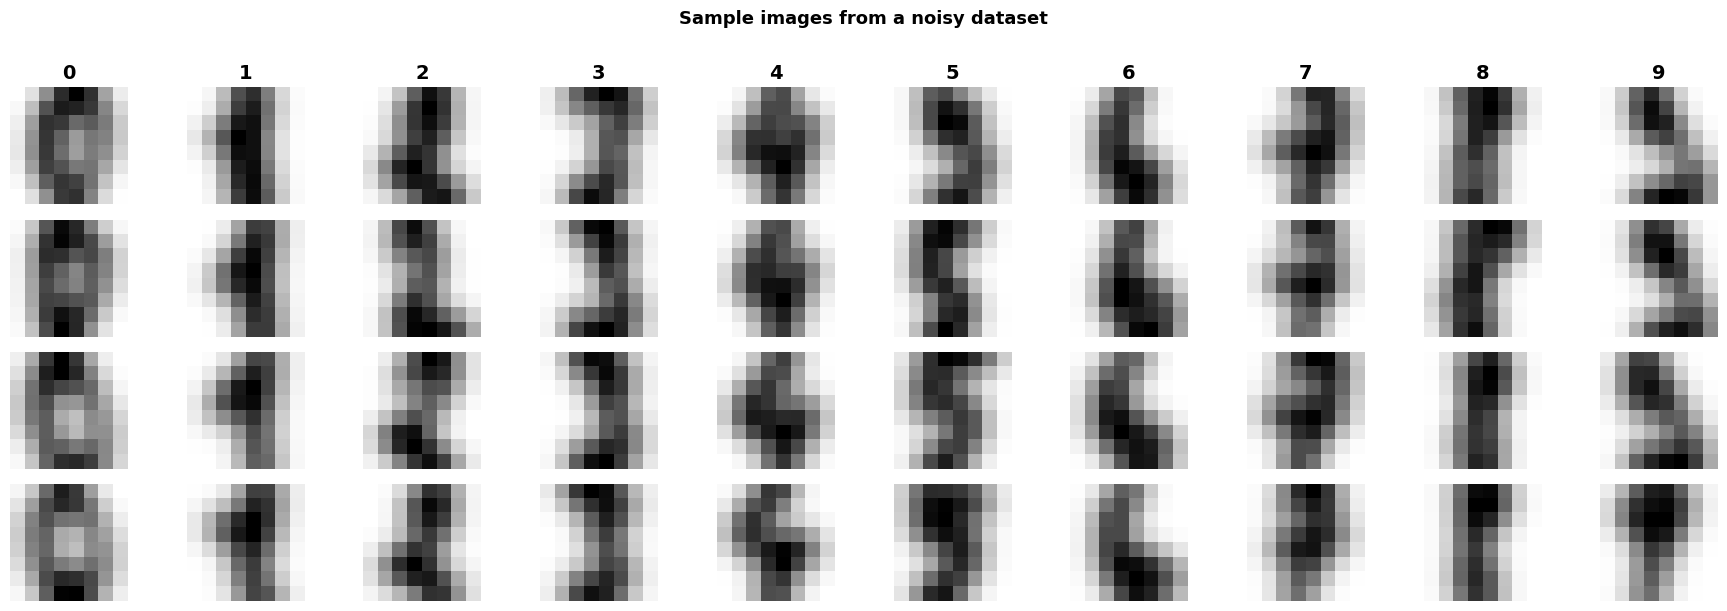

In [11]:
from sklearn import svm
from sklearn import metrics
from scipy.ndimage import gaussian_filter

X_train_noisy = X_train.copy()
# image_noise = np.random.RandomState(SEED).normal(loc=0.0, scale=8.0, size=X_train_noisy.shape)
# X_train_noisy += image_noise

# Apply 2D Gaussian blur to each image
n_samples = X_train_noisy.shape[0]
image_size = int(np.sqrt(X_train_noisy.shape[1]))  # 8x8 for digits dataset
for i in range(n_samples):
    img = X_train_noisy[i].reshape(image_size, image_size)
    img_blurred = gaussian_filter(img, sigma=0.9)
    X_train_noisy[i] = img_blurred.flatten()

plot_example_data(X_train_noisy, y_train, title="Sample images from a noisy dataset")


In [12]:
# Model training

# Create a classifier: a support vector classifier
clean_model = svm.SVC(gamma=0.001)
noisy_model = svm.SVC(gamma=0.001)

clean_model.fit(X_train, y_train)
noisy_model.fit(X_train_noisy, y_train)


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",0.001
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


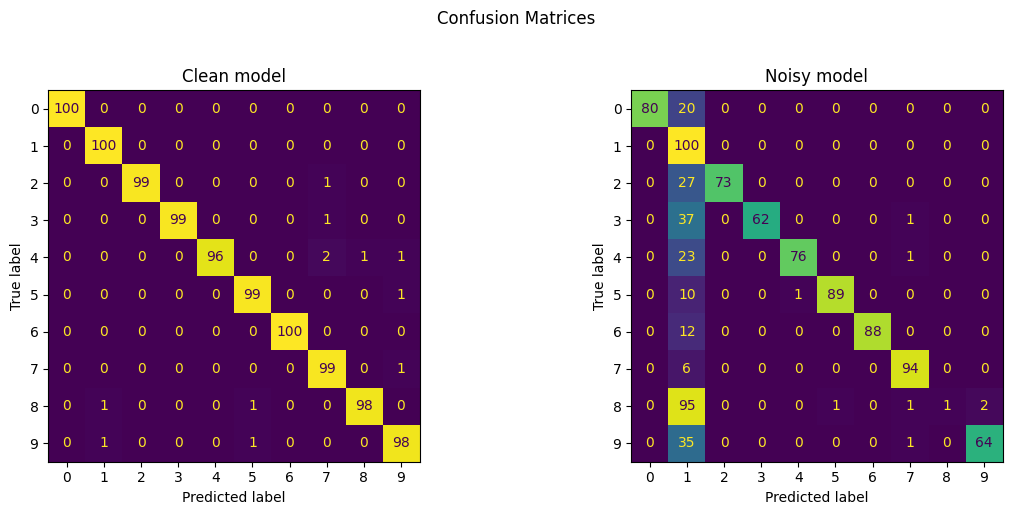

In [13]:
# Model evaluation

# predict the value of the digit on the test subset
clean_model_predicted = clean_model.predict(X_test)
noisy_model_predicted = noisy_model.predict(X_test)

# plot the results
plot_two_confusion_matrices(
    y_test, 
    clean_model_predicted, "Clean model", 
    noisy_model_predicted, "Noisy model"
    )

## 📊 Scenario 4: Data Quantity
### *Was there enough training data?*

Deep learning models need to see *many* examples to learn robust patterns. When the training set is small, the model may learn the specific training examples by heart — a problem called **overfitting** — but fail to generalise to new patients.

This is a critical challenge in radiotherapy AI, because rare cancer types may have very few patients available for training.

In this demo: we compare models trained on **10, 20, 30, ..., 400 images**.

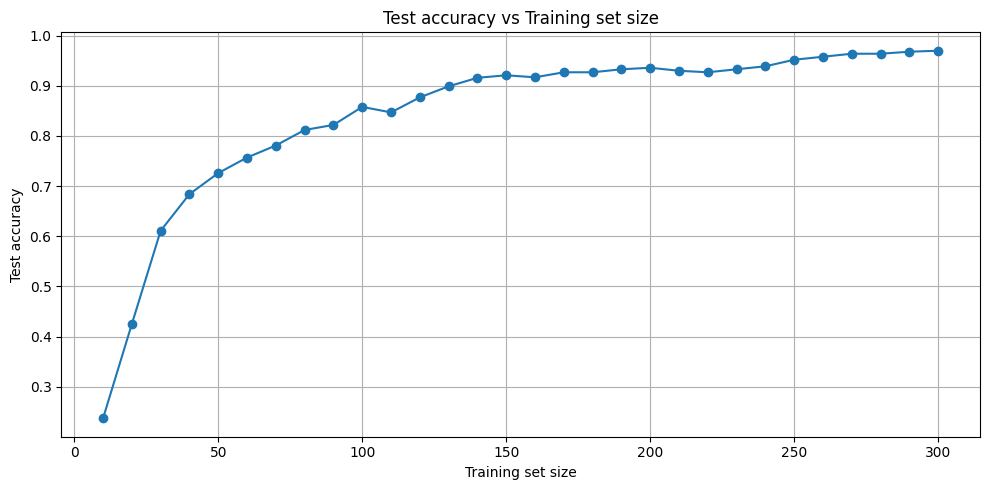

In [14]:
# Retrain SVM with increasing training-set sizes and report test accuracy
full_size = len(X_train)
sizes = list(range(10, 300 + 1, 10))
# if sizes[-1] != full_size:
#     sizes.append(full_size)

accuracies = []
rng = np.random.RandomState(SEED)
perm = rng.permutation(full_size)

for n in sizes:
    idx = perm[:n]
    X_sub = X_train[idx]
    y_sub = y_train[idx]

    model = svm.SVC(gamma=0.001)
    model.fit(X_sub, y_sub)

    y_pred = model.predict(X_test)
    acc = metrics.accuracy_score(y_test, y_pred)
    accuracies.append(acc)

plt.figure(figsize=(10, 5))
plt.plot(sizes, accuracies, marker='o')
plt.xlabel("Training set size")
plt.ylabel("Test accuracy")
plt.title("Test accuracy vs Training set size")
plt.grid(True)
plt.tight_layout()
plt.show()

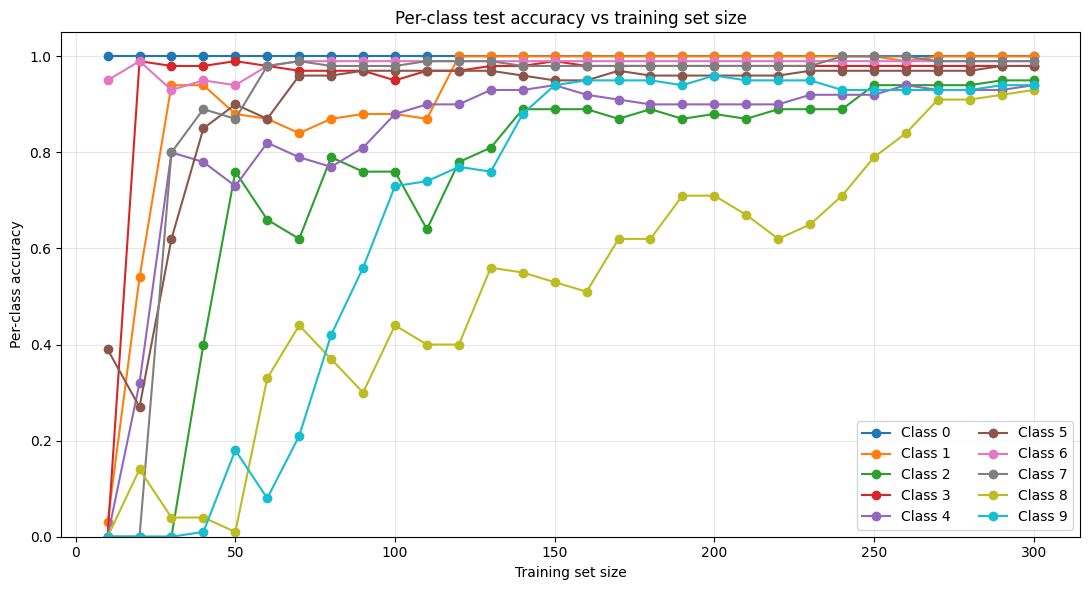

: 

In [ ]:
# Retrain SVM with increasing training-set sizes and report test accuracy
full_size = len(X_train)
sizes = list(range(10, 300 + 1, 10))
# if sizes[-1] != full_size:
#     sizes.append(full_size)

accuracies = []
classes = np.unique(y_test)
per_class_accuracies = {c: [] for c in classes}

rng = np.random.RandomState(SEED)
perm = rng.permutation(full_size)

for n in sizes:
    idx = perm[:n]
    X_sub = X_train[idx]
    y_sub = y_train[idx]

    model = svm.SVC(gamma=0.001)
    model.fit(X_sub, y_sub)

    y_pred = model.predict(X_test)
    accuracies.append(metrics.accuracy_score(y_test, y_pred))

    for c in classes:
        class_mask = y_test == c
        per_class_accuracies[c].append((y_pred[class_mask] == c).mean())

plt.figure(figsize=(11, 6))
for c in classes:
    plt.plot(sizes, per_class_accuracies[c], marker="o", linewidth=1.5, label=f"Class {c}")

plt.xlabel("Training set size")
plt.ylabel("Per-class accuracy")
plt.title("Per-class test accuracy vs training set size")
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.legend(ncol=2)
plt.tight_layout()
plt.show()